In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor  
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
df = pd.read_csv("C:\\Users\\pushp\\OneDrive\\Desktop\\AI &ML project\\student-score-prediction-1\\data\\student_performance_processed.csv")

target = "Exam_Score"

X = df.drop(columns= [target])
Y = df[target]

In [3]:
X_train,X_test,Y_train,Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42

)

In [4]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "KNN": KNeighborsRegressor()
}

In [5]:
results = []

for name,model in models.items():
    model.fit(X_train,Y_train)

    predictions = model.predict(X_test)

    mae = mean_absolute_error(Y_test,predictions)
    rmse = np.sqrt(mean_squared_error(Y_test, predictions))
    r2 = r2_score(Y_test,predictions)


    results.append({
        "Model": name,
        "MAE": round(mae,3),
        "RMSE": round(rmse,3),
        "R2 Score": round(r2,4) 
    })

In [6]:
results_df = pd.DataFrame(results)

results_df + results_df.sort_values(
    by = "R2 Score",
    ascending = False
)

,Model,MAE,RMSE,R2 Score
0,Linear RegressionLinear Regression,0.000,0.000,2.0000
1,Decision TreeDecision Tree,2.650,3.776,1.4958
2,Random ForestRandom Forest,1.776,2.724,1.7374
3,Gradient BoostingGradient Boosting,1.358,2.426,1.7918
4,KNNKNN,3.062,4.958,1.1308


In [ ]:
best_model = results_df.iloc[0]

print("Best Model:",best_model["Model"])

Best Modek: Linear Regression


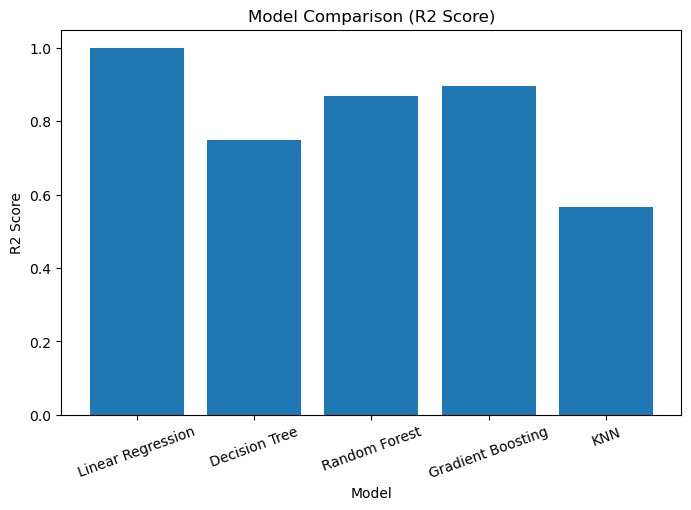

In [8]:
plt.figure(figsize=(8,5))

plt.bar(results_df["Model"],results_df["R2 Score"])

plt.title("Model Comparison (R2 Score)")
plt.xlabel("Model")
plt.ylabel("R2 Score")

plt.xticks(rotation=20)
plt.show()

In [9]:
results_df.to_csv("C:\\Users\\pushp\\OneDrive\\Desktop\\AI &ML project\\student-score-prediction-1\\data\\model_comparison_results.csv", index=False)

print("Model comparison results saved successfully!")

Model comparison results saved successfully!
